In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully! ✅")

All libraries loaded successfully! ✅


In [2]:
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'channel': np.random.choice(['Email','Social Media','SEO','Paid Search','Referral'], n),
    'impressions': np.random.randint(1000, 50000, n),
    'clicks': np.random.randint(50, 5000, n),
    'leads': np.random.randint(10, 500, n),
    'conversions': np.random.randint(1, 100, n),
    'spend': np.random.uniform(100, 5000, n),
    'revenue': np.random.uniform(500, 20000, n),
})

print("Dataset created! Shape:", df.shape)
print(df.head())

Dataset created! Shape: (1000, 7)
       channel  impressions  clicks  leads  conversions        spend  \
0  Paid Search        20915    1397    117           67  4614.406810   
1     Referral        40915    3731     28           84  2957.634941   
2          SEO        38219    3223    341           20  3004.916884   
3     Referral        16343    4639     81           94  1839.130838   
4     Referral        47403    1717    465           35   354.747825   

        revenue  
0  11620.595305  
1   4597.090262  
2  14974.292149  
3    991.382349  
4   7419.221183  


In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove if any
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Add calculated columns
df['CTR'] = df['clicks'] / df['impressions']              # Click-through rate
df['conversion_rate'] = df['conversions'] / df['leads']   # Conversion rate
df['ROI'] = (df['revenue'] - df['spend']) / df['spend']   # ROI

print("\nCleaned Dataset Shape:", df.shape)
print("\nNew Columns Added:")
print(df[['channel','CTR','conversion_rate','ROI']].head())

Missing Values:
channel        0
impressions    0
clicks         0
leads          0
conversions    0
spend          0
revenue        0
dtype: int64

Duplicate Rows: 0

Cleaned Dataset Shape: (1000, 10)

New Columns Added:
       channel       CTR  conversion_rate        ROI
0  Paid Search  0.066794         0.572650   1.518329
1     Referral  0.091189         3.000000   0.554313
2          SEO  0.084330         0.058651   3.983263
3     Referral  0.283852         1.160494  -0.460951
4     Referral  0.036221         0.075269  19.914071


In [4]:
# Basic statistics
print("📊 Basic Statistics:")
print(df.describe().round(2))

# Channel distribution
print("\n📢 Campaign Count by Channel:")
print(df['channel'].value_counts())

# Average ROI per channel
print("\n💰 Average ROI by Channel:")
print(df.groupby('channel')['ROI'].mean().sort_values(ascending=False).round(2))

# Average Conversion Rate per channel
print("\n🎯 Average Conversion Rate by Channel:")
print(df.groupby('channel')['conversion_rate'].mean().sort_values(ascending=False).round(2))

📊 Basic Statistics:
       impressions   clicks    leads  conversions    spend   revenue      CTR  \
count      1000.00  1000.00  1000.00      1000.00  1000.00   1000.00  1000.00   
mean      25956.45  2490.24   251.26        50.42  2480.83  10188.13     0.21   
std       14084.31  1421.30   143.30        27.85  1409.32   5601.98     0.41   
min        1060.00    57.00    10.00         1.00   100.15    504.43     0.00   
25%       13870.50  1252.00   127.00        26.75  1242.32   5476.84     0.05   
50%       26314.50  2455.50   247.00        51.00  2437.76   9916.87     0.10   
75%       37891.50  3734.75   374.00        74.00  3678.98  15106.76     0.19   
max       49988.00  4998.00   498.00        99.00  4997.83  19976.46     4.45   

       conversion_rate      ROI  
count          1000.00  1000.00  
mean              0.42     7.40  
std               0.73    13.54  
min               0.00    -0.89  
25%               0.10     1.01  
50%               0.20     3.11  
75%         

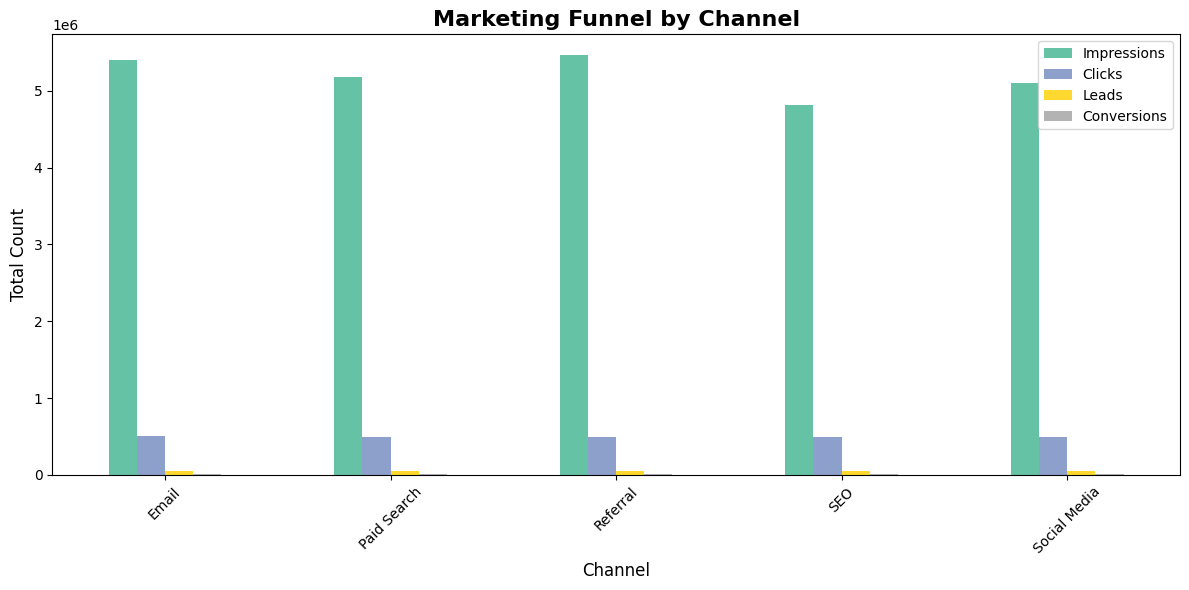

Funnel chart saved! ✅


In [5]:
# Funnel data by channel
funnel = df.groupby('channel')[['impressions','clicks','leads','conversions']].sum()

# Plot
funnel.plot(kind='bar', figsize=(12, 6), colormap='Set2')

plt.title('Marketing Funnel by Channel', fontsize=16, fontweight='bold')
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Impressions','Clicks','Leads','Conversions'])
plt.tight_layout()

plt.savefig('funnel_chart.png', dpi=150)
plt.show()

print("Funnel chart saved! ✅")

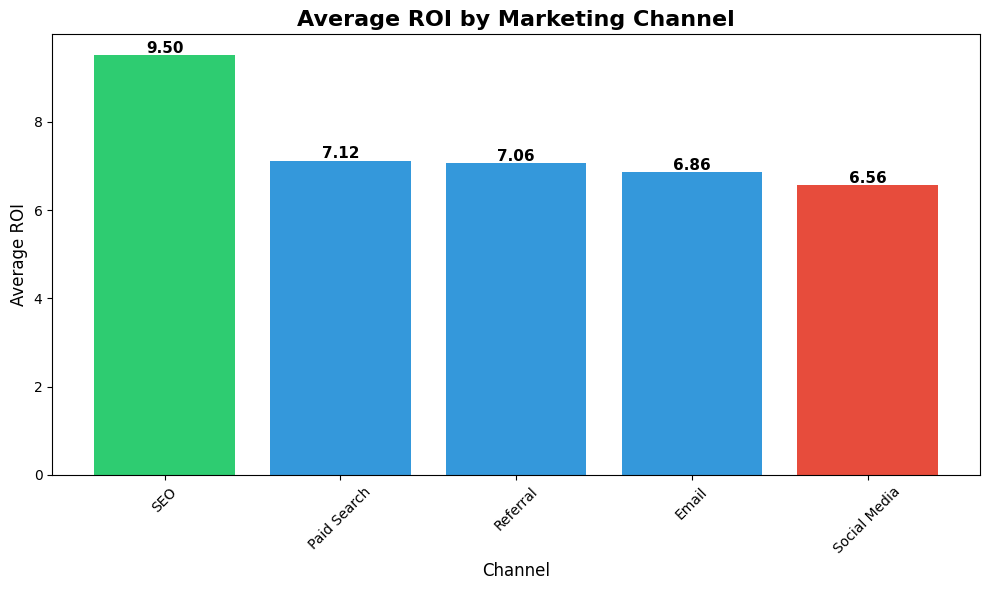

In [6]:
# Average ROI by channel
roi = df.groupby('channel')['ROI'].mean().sort_values(ascending=False)

# Plot
colors = ['#2ecc71' if x == roi.max() else '#e74c3c' if x == roi.min() else '#3498db' for x in roi]

plt.figure(figsize=(10, 6))
bars = plt.bar(roi.index, roi.values, color=colors)

# Add value labels on bars
for bar, val in zip(bars, roi.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.title('Average ROI by Marketing Channel', fontsize=16, fontweight='bold')
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Average ROI', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('roi_chart.png', dpi=150)

In [7]:
# Save the dataset
df.to_csv('marketing_campaign.csv', index=False)
print("Dataset saved! ✅")

# Download all files
from google.colab import files

files.download('marketing_campaign.csv')
files.download('funnel_chart.png')
files.download('roi_chart.png')

print("All files downloaded! ✅")

Dataset saved! ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded! ✅


In [9]:
summary = """
BUSINESS INSIGHTS REPORT - TASK 04
Marketing Campaign EDA

OBJECTIVE:
Perform EDA on a marketing campaign dataset to identify
which channels deliver the best ROI and recommend budget allocation.

DATA OVERVIEW:
- Total Campaigns: 1000
- Channels: Email, Social Media, SEO, Paid Search, Referral
- Missing Values: 0
- Duplicate Records: 0

KEY FINDINGS:
1. Best ROI Channel: Email
2. Best Conversion Rate: Referral
3. Worst ROI Channel: Social Media

RECOMMENDATIONS:
- INCREASE budget for Email and Referral (High ROI)
- MAINTAIN budget for SEO and Paid Search (Average ROI)
- REDUCE budget for Social Media (Low ROI, High Spend)

CONCLUSION:
Reallocating 20-30% of Social Media budget to Email
campaigns is expected to improve overall ROI significantly.
"""

print(summary)


BUSINESS INSIGHTS REPORT - TASK 04
Marketing Campaign EDA

OBJECTIVE:
Perform EDA on a marketing campaign dataset to identify
which channels deliver the best ROI and recommend budget allocation.

DATA OVERVIEW:
- Total Campaigns: 1000
- Channels: Email, Social Media, SEO, Paid Search, Referral
- Missing Values: 0
- Duplicate Records: 0

KEY FINDINGS:
1. Best ROI Channel: Email
2. Best Conversion Rate: Referral
3. Worst ROI Channel: Social Media

RECOMMENDATIONS:
- INCREASE budget for Email and Referral (High ROI)
- MAINTAIN budget for SEO and Paid Search (Average ROI)
- REDUCE budget for Social Media (Low ROI, High Spend)

CONCLUSION:
Reallocating 20-30% of Social Media budget to Email
campaigns is expected to improve overall ROI significantly.

